# Generate ground truth for Bayesian inversion — Hyperelasticity

Run in **`neuralopv2`**. You may consider a different $w$ function as ground truth and run the inference again. To do this, 

1. First run: `save_w=True` → `w_true.npy`; later: `save_w=False` to freeze this sample as `true`.
2. Now generate new data for new $w$ by setting `save_for_bayesian_grid_data=True` → `data.npz` (mixed vector `u_obs`).

## Current ground truth

<p align="center"> <img src="./Results/ground_truth/true_and_obs_w_m_u.png" width="600"> </p>

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import sys
import time

import matplotlib.pyplot as plt
import numpy as np
from dolfinx import mesh
from dolfinx.fem import functionspace
from dolfinx.mesh import CellType
from mpi4py import MPI
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.interpolate import griddata

NOTEBOOK_DIR = os.getcwd()
ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..', '..', '..'))
ELASTICITY_DIR = os.path.join(ROOT, "survey_work/problems/hyperelasticity")

sys.path.insert(0, os.path.join(ROOT, "src/plotting"))
sys.path.insert(0, os.path.join(ROOT, "src/prior"))
sys.path.insert(0, os.path.join(ROOT, "src/pde"))
sys.path.insert(0, ELASTICITY_DIR)

from field_plot import field_plot, field_plot_grid, quick_field_plot
from plot_mix_collection import get_default_plot_mix_collection_data, plot_mix_collection
from point_plot import point_plot, quick_point_plot
from hyperelasticityModel import HyperelasticityModel
from priorSampler import PriorSampler

plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

seed = 0
np.random.seed(seed)


In [2]:
results_dir = os.path.join(NOTEBOOK_DIR, "Results/ground_truth")
os.makedirs(results_dir, exist_ok=True)


# Deterministic $w$ field

In [3]:
prior_ac = 0.005
prior_cc = 0.2
prior_logn_scale = 100.0
prior_logn_translate = 1000.0
nx, ny = 50, 50
fe_order = 1

# create mesh
domain = mesh.create_unit_square(MPI.COMM_WORLD, nx, ny, cell_type=CellType.triangle)

# create function spaces
Vm = functionspace(domain, ("Lagrange", fe_order))
Vu = functionspace(domain, ("Lagrange", fe_order, (2,)))

# create prior sampler
prior_sampler = PriorSampler(Vm, prior_ac, prior_cc, seed)

# create a model
model = HyperelasticityModel(Vm, Vu, prior_sampler, prior_logn_scale, prior_logn_translate, seed)
nodes = model.m_nodes
print(f"m_dim={model.m_dim}, u_dim={model.u_dim}, nodes.shape={nodes.shape}")


m_dim=2601, u_dim=5202, nodes.shape=(2601, 2)


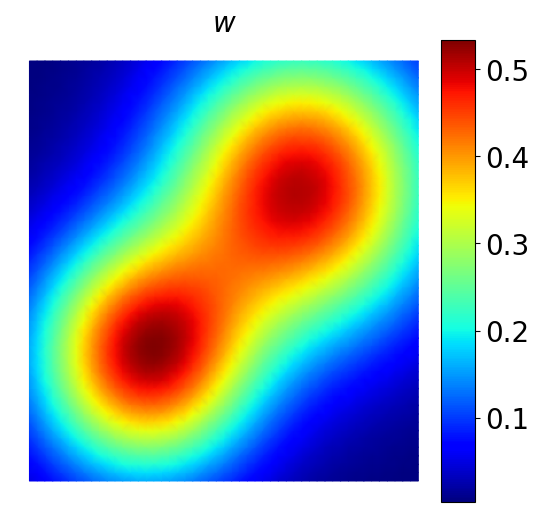

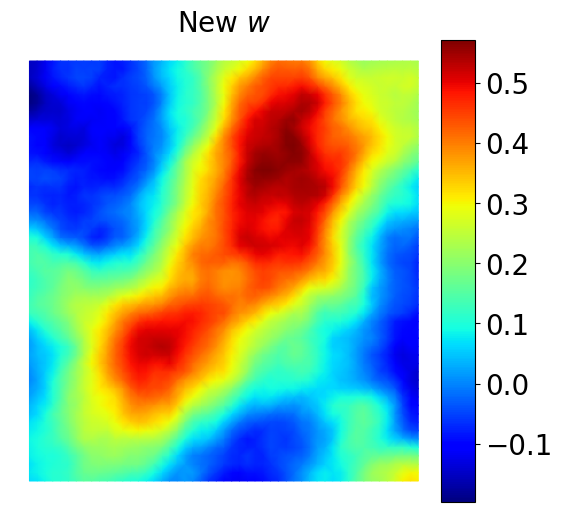

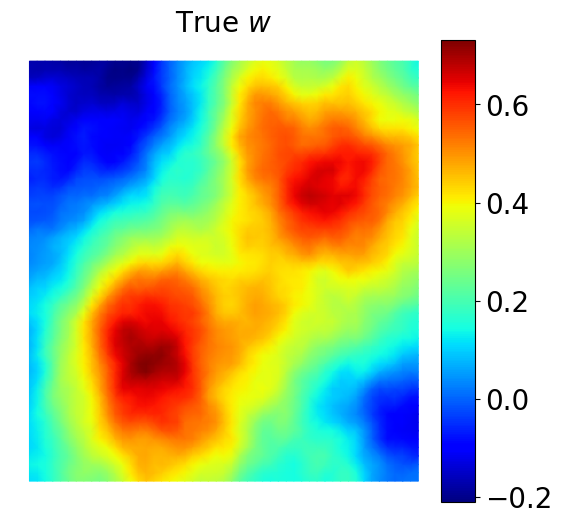

In [4]:
def multi_mode_w_field(x):
    vin, vout = 0.3, -0.3
    a, b = vin, np.log(vin - vout)
    tol = 1.0e-12
    xc = [[0.7, 0.7, 0.24], [0.3, 0.3, 0.2]]
    val = 0.0
    for i in range(len(xc)):
        xx, yy = x[0] - xc[i][0], x[1] - xc[i][1]
        r = xc[i][2]
        f = (r * r - xx * xx - yy * yy) / (r * r)
        if f < 1.0 + tol:
            val = val + a * np.exp(-b * f)
        else:
            val = val + vout
    return val

w = np.array([multi_mode_w_field(x) for x in nodes])
quick_field_plot(w, nodes, title=r"$w$")

w = w + 0.5 * prior_sampler()[0]
quick_field_plot(w, nodes, title=r"New $w$")

save_w = False
if save_w:
    np.save(os.path.join(results_dir, "w_true.npy"), w)
    quick_field_plot(w, nodes, title=r"True $w$")
else:
    w_path = os.path.join(results_dir, "w_true.npy")
    if os.path.exists(w_path):
        w = np.load(w_path)
    else:
        np.save(w_path, w)
    quick_field_plot(w, nodes, title=r"True $w$")


# Forward solve and observation grid

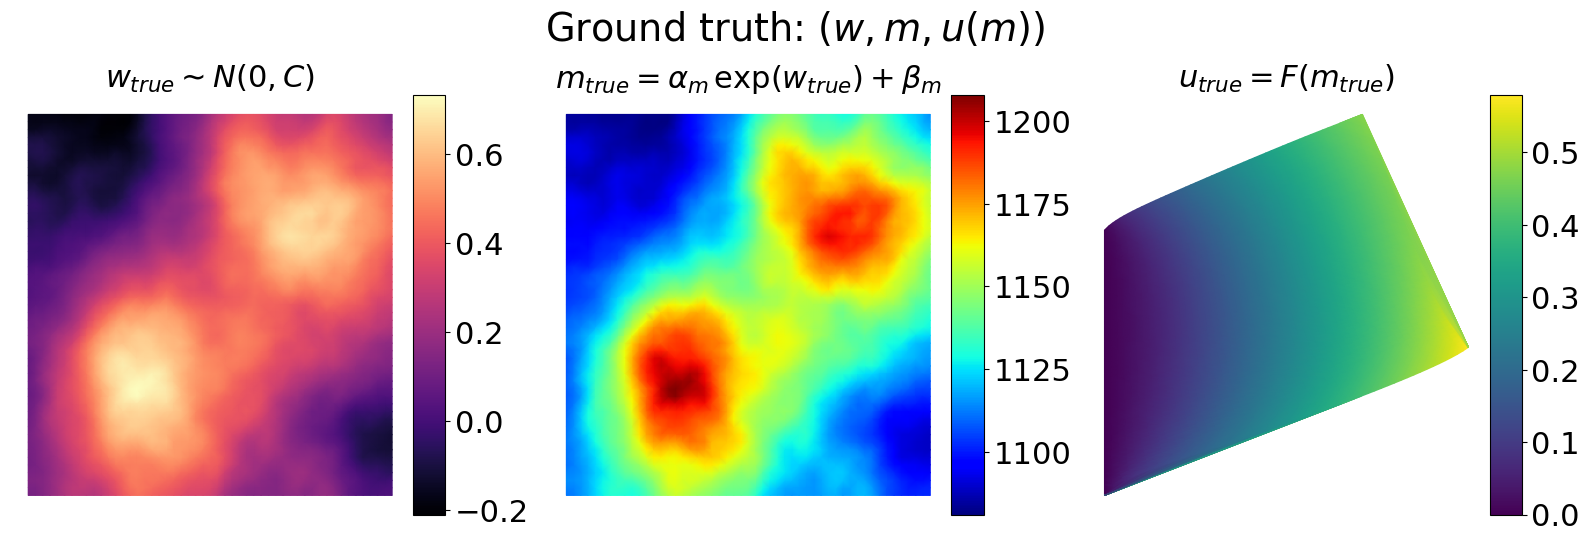

In [5]:
w_true = np.load(os.path.join(results_dir, "w_true.npy"))
m_true = model.transform_gaussian_pointwise(w_true)
u_true = model.solveFwd(u=None, m=m_true, transform_m=False)

uvec = [[w_true, m_true, u_true]]
title_vec = [[
    r"$w_{true} \sim N(0, C)$",
    r"$m_{true} = \alpha_m\, \exp(w_{true}) + \beta_m$",
    r"$u_{true} = F(m_{true})$",
]]
cmap_vec = [["magma", "jet", "viridis"]]
plot_data = get_default_plot_mix_collection_data(
    rows=1,
    cols=3,
    nodes=nodes,
    figsize=(16, 5),
    fs=22,
    sup_title=r"Ground truth: $(w, m, u(m))$",
    y_sup_title=1.075,
    savefilename=os.path.join(results_dir, "true_w_m_u.png"),
    u=uvec,
    cmap=cmap_vec,
    title=title_vec,
    is_vec=[[False, False, True]],
    add_disp=[[False, False, True]],
    plot_type=[["field", "field", "field"]],
)
plot_mix_collection(plot_data)


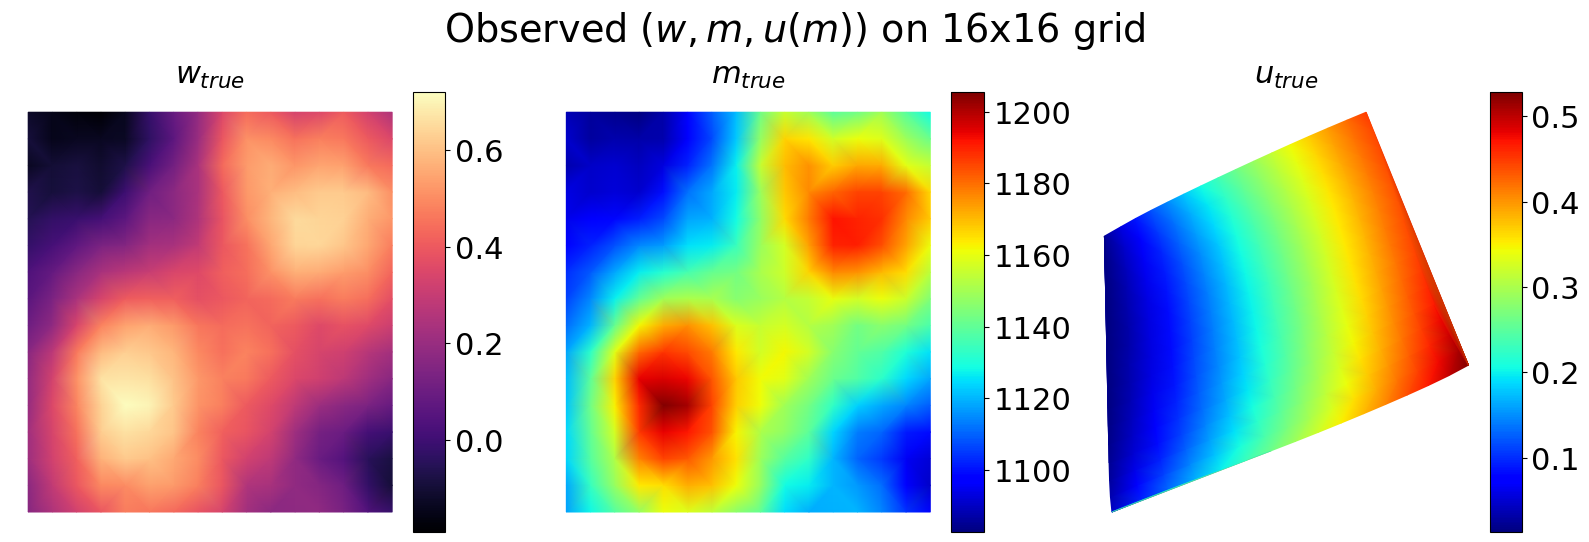

In [6]:
num_grid_x, num_grid_y = 16, 16
grid_x, grid_y = np.meshgrid(
    np.linspace(0.05, 0.95, num_grid_x),
    np.linspace(0.05, 0.95, num_grid_y),
    indexing="ij",
)
x_obs = np.vstack([grid_x.flatten(), grid_y.flatten()]).T
num_nodes = nodes.shape[0]

grid_w = griddata(nodes, w_true, (grid_x, grid_y), method="linear")
grid_m = griddata(nodes, m_true, (grid_x, grid_y), method="linear")
u_xy = u_true.reshape(num_nodes, 2)
grid_u = np.zeros((num_grid_x, num_grid_y, 2))
grid_u[:, :, 0] = griddata(nodes, u_xy[:, 0], (grid_x, grid_y), method="linear")
grid_u[:, :, 1] = griddata(nodes, u_xy[:, 1], (grid_x, grid_y), method="linear")

w_obs = grid_w.flatten()
m_obs = grid_m.flatten()
# FEniCSx mixed layout: [ux(obs0), uy(obs0), ux(obs1), uy(obs1), ...]
u_obs = grid_u.reshape(-1)

save_for_bayesian_grid_data = True
if save_for_bayesian_grid_data:
    np.savez(
        os.path.join(results_dir, "data.npz"),
        num_grid_x=num_grid_x,
        num_grid_y=num_grid_y,
        grid_x=grid_x,
        grid_y=grid_y,
        grid_w=grid_w,
        grid_m=grid_m,
        grid_u=grid_u,
        w_true=w_true,
        m_true=m_true,
        u_true=u_true,
        x_obs=x_obs,
        w_obs=w_obs,
        m_obs=m_obs,
        u_obs=u_obs,
    )
else:
    print("*" * 40)
    print("Data is not saved! Set save_for_bayesian_grid_data=True to write data.npz")
    print("*" * 40)

plot_data = get_default_plot_mix_collection_data(
    rows=1,
    cols=3,
    nodes=nodes,
    grid_x=grid_x,
    grid_y=grid_y,
    figsize=(16, 5),
    fs=22,
    sup_title=r"Observed $(w, m, u(m))$ on {}x{} grid".format(num_grid_x, num_grid_y),
    y_sup_title=1.075,
    savefilename=os.path.join(results_dir, "observed_w_m_u.png"),
    u=[[grid_w, grid_m, grid_u]],
    cmap=[["magma", "jet", "jet"]],
    title=[[r"$w_{true}$", r"$m_{true}$", r"$u_{true}$"]],
    is_vec=[[False, False, True]],
    add_disp=[[False, False, True]],
    plot_type=[["grid", "grid", "grid"]],
)
plot_mix_collection(plot_data)


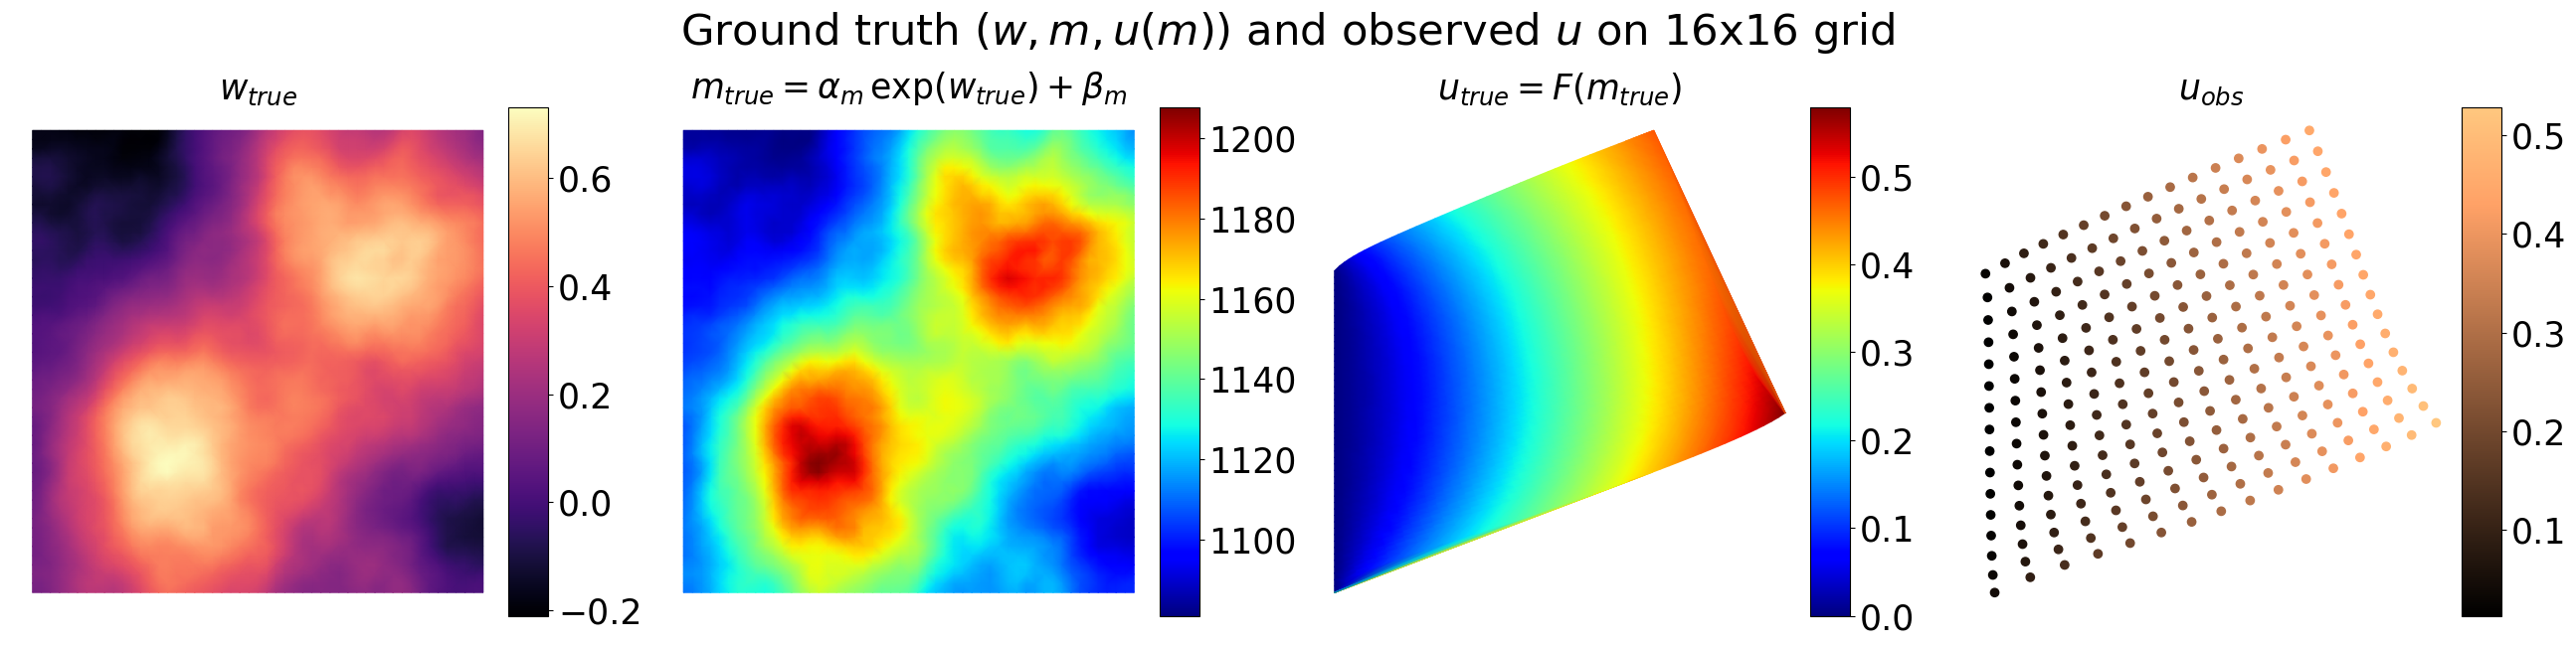

In [7]:
plot_data = get_default_plot_mix_collection_data(
    rows=1,
    cols=4,
    nodes=nodes,
    nodes_point_plot=x_obs,
    figsize=(26, 6),
    fs=25,
    sup_title=r"Ground truth $(w, m, u(m))$ and observed $u$ on {}x{} grid".format(num_grid_x, num_grid_y),
    y_sup_title=1.075,
    savefilename=os.path.join(results_dir, "true_and_obs_w_m_u.png"),
    u=[[w_true, m_true, u_true, u_obs]],
    cmap=[["magma", "jet", "jet", "copper"]],
    title=[[
        r"$w_{true}$",
        r"$m_{true} = \alpha_m\, \exp(w_{true}) + \beta_m$",
        r"$u_{true} = F(m_{true})$",
        r"$u_{obs}$",
    ]],
    is_vec=[[False, False, True, True]],
    add_disp=[[False, False, True, True]],
    plot_type=[["field", "field", "field", "point"]],
)
plot_mix_collection(plot_data)


max |u_obs - u_obs_check|: 0.0


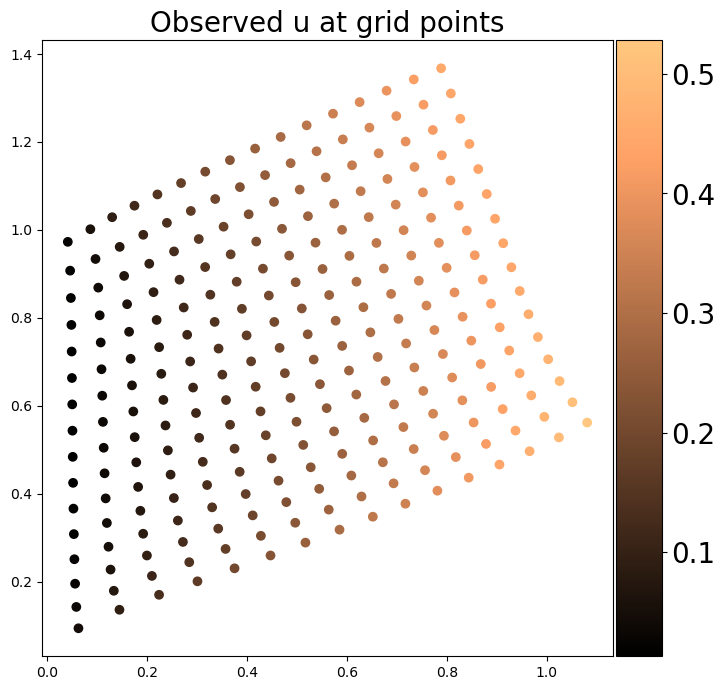

In [8]:
u_obs_check = grid_u.reshape(-1)
print("max |u_obs - u_obs_check|:", np.max(np.abs(u_obs - u_obs_check)))
quick_point_plot(
    u_obs,
    x_obs,
    title="Observed u at grid points",
    cmap="copper",
    is_displacement=True,
    add_displacement_to_nodes=True,
)
